In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [2]:
walmart_df = pd.read_csv('Walmart_sales.csv',
                         parse_dates=['Date'],
                         date_format='%d-%m-%Y')
walmart_df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
print(walmart_df.shape)
print(walmart_df.columns)
walmart_df.dtypes

(6435, 8)
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='str')


Store                    int64
Date            datetime64[us]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [4]:
walmart_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [5]:
walmart_df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


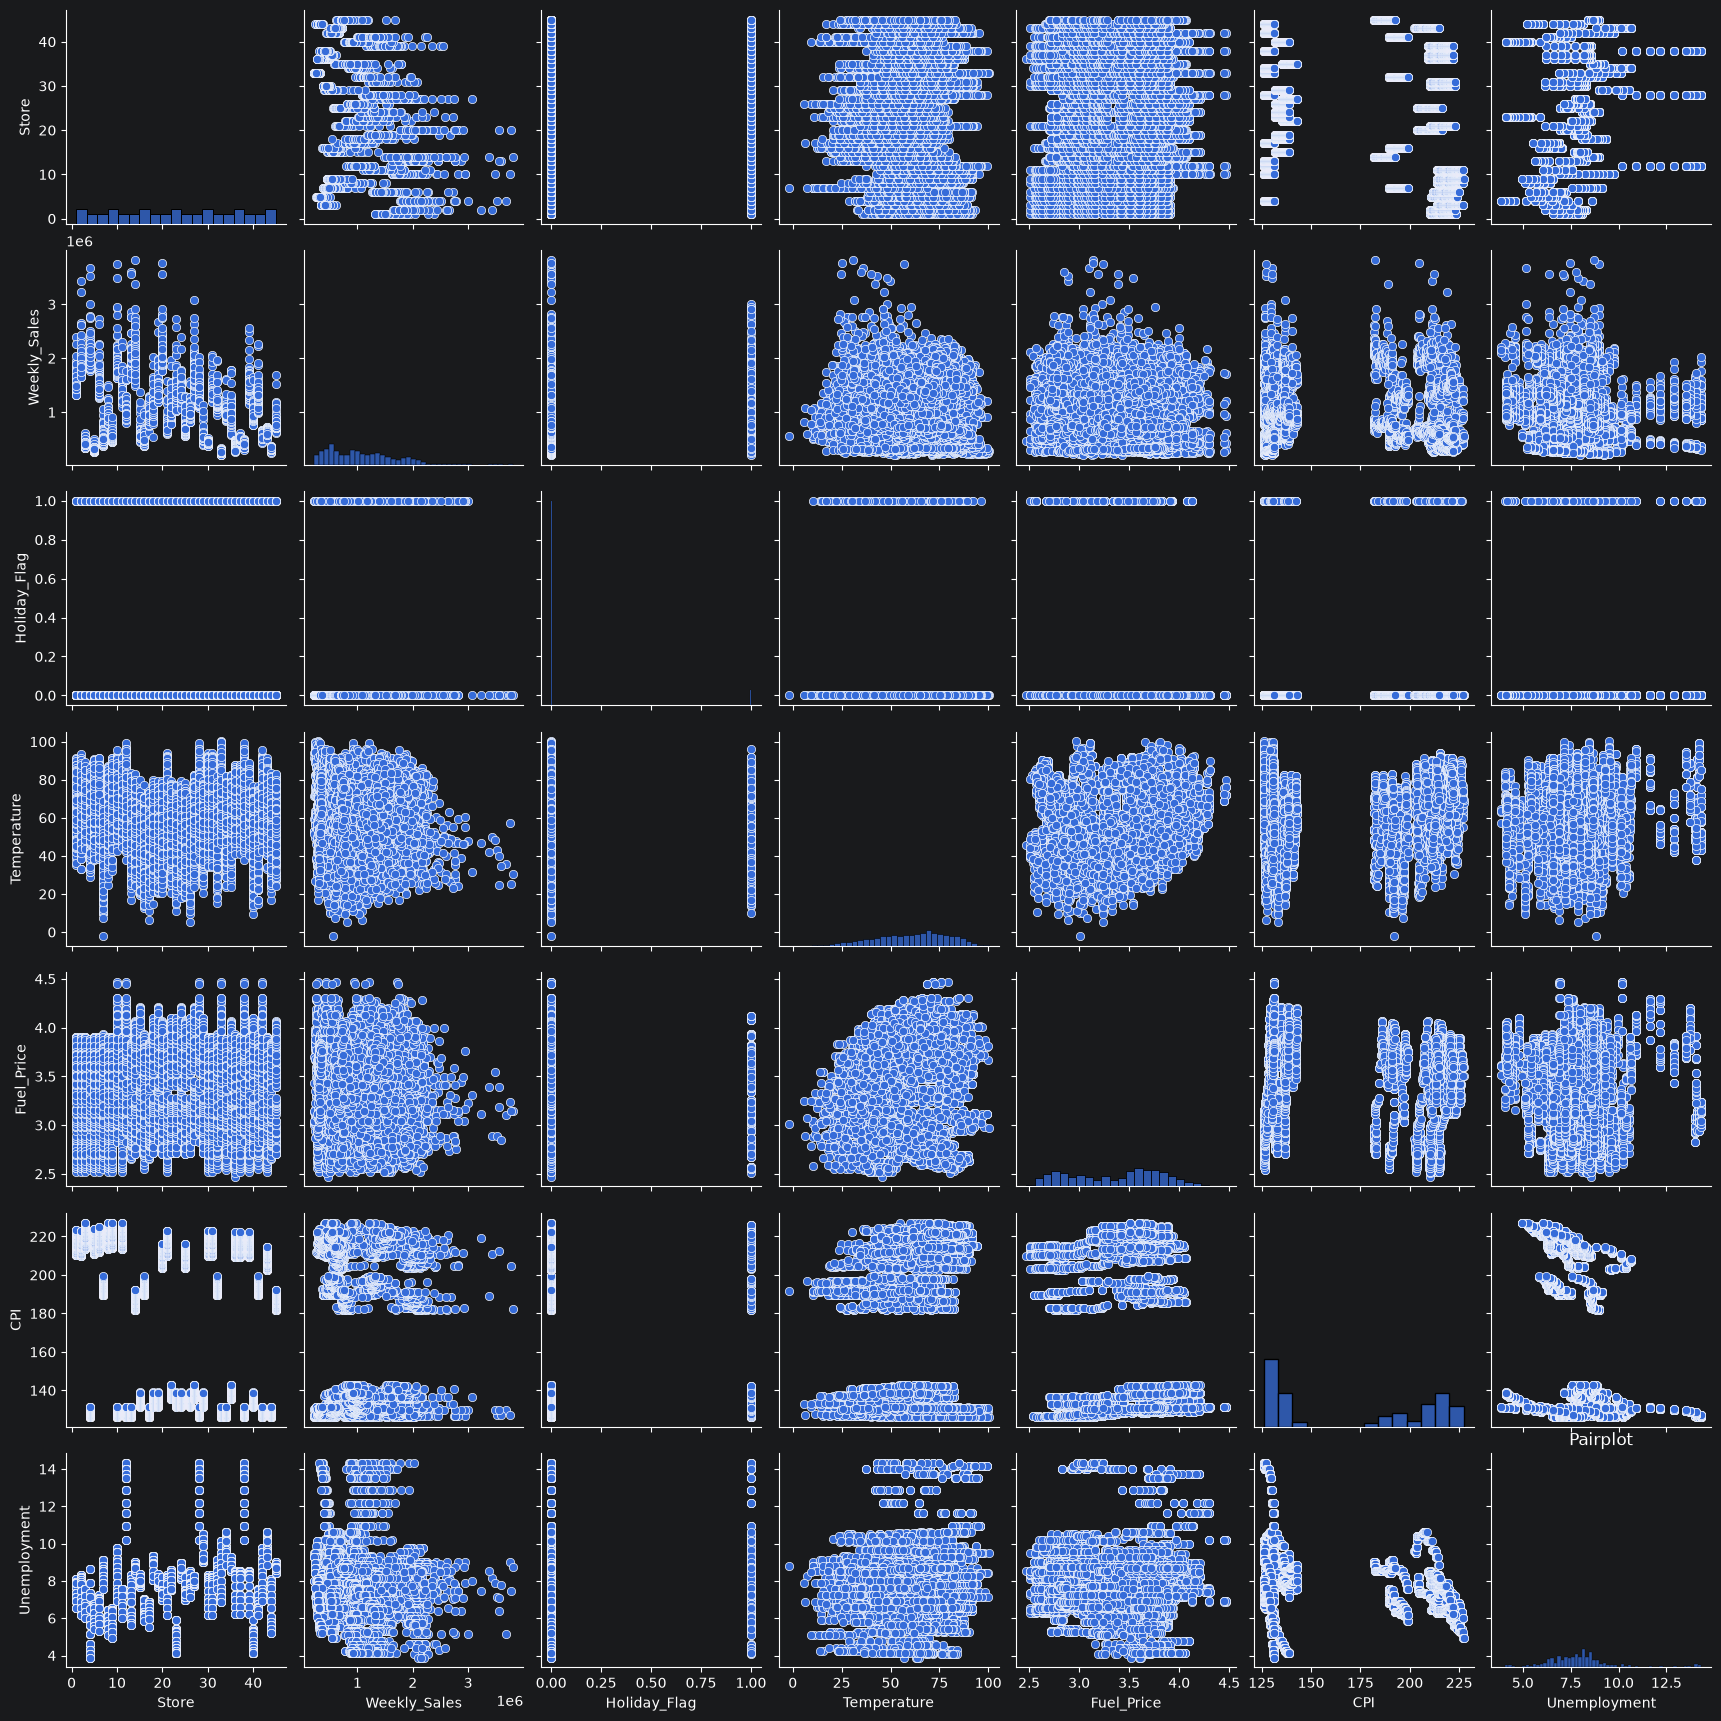

In [6]:
sns.pairplot(data=walmart_df)
plt.title("Pairplot")
plt.show()

In [7]:
corr_matrix = walmart_df.corr()

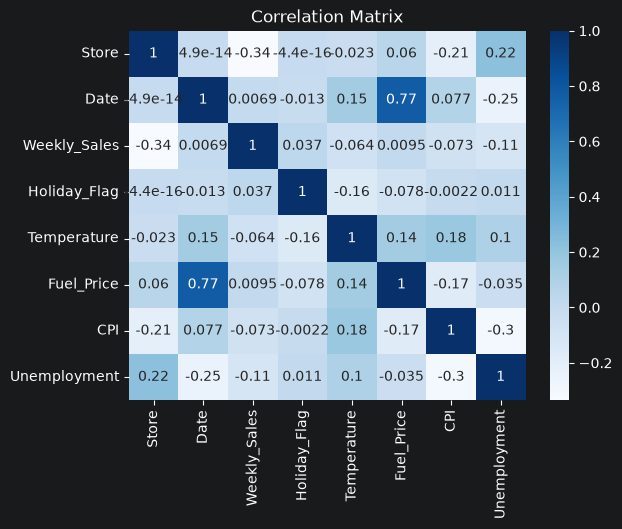

In [9]:
sns.heatmap(corr_matrix, cmap='Blues', annot=True)
plt.title('Correlation Matrix')
plt.show()

In [360]:
X = walmart_df.drop(['Weekly_Sales'],axis=1)
X.columns
X['Year'] = walmart_df['Date'].dt.year
X['Month'] = walmart_df['Date'].dt.month
X['Day'] = walmart_df['Date'].dt.day
X.drop('Date', axis=1, inplace=True)
y = walmart_df['Weekly_Sales']
y.head()
print(X.head())

   Store  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment  \
0      1             0        42.31       2.572  211.096358         8.106   
1      1             1        38.51       2.548  211.242170         8.106   
2      1             0        39.93       2.514  211.289143         8.106   
3      1             0        46.63       2.561  211.319643         8.106   
4      1             0        46.50       2.625  211.350143         8.106   

   Year  Month  Day  
0  2010      2    5  
1  2010      2   12  
2  2010      2   19  
3  2010      2   26  
4  2010      3    5  


In [361]:
X_scaled = X.copy()
X_scaled.drop(['Fuel_Price'], axis=1, inplace=True)
# Fuel Price gives us more noise than real insight, as it is discovered later, so I deleted it
X_scaled['Store'] = X_scaled['Store'].astype('str')
X_scaled = pd.get_dummies(data=X_scaled, columns=['Store'],drop_first=True, dtype=np.int64)
X_scaled

,Holiday_Flag,Temperature,CPI,Unemployment,Year,Month,Day,Store_10,Store_11,Store_12,...,Store_41,Store_42,Store_43,Store_44,Store_45,Store_5,Store_6,Store_7,Store_8,Store_9
0,0,42.31,211.096358,8.106,2010,2,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,38.51,211.242170,8.106,2010,2,12,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,39.93,211.289143,8.106,2010,2,19,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,46.63,211.319643,8.106,2010,2,26,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,46.50,211.350143,8.106,2010,3,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,0,64.88,192.013558,8.684,2012,9,28,0,0,0,...,0,0,0,0,1,0,0,0,0,0
6431,0,64.89,192.170412,8.667,2012,10,5,0,0,0,...,0,0,0,0,1,0,0,0,0,0
6432,0,54.47,192.327265,8.667,2012,10,12,0,0,0,...,0,0,0,0,1,0,0,0,0,0
6433,0,56.47,192.330854,8.667,2012,10,19,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [362]:
model = LinearRegression()
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
col_names = ['Temperature','CPI','Unemployment','Year','Month','Day']
X_train[col_names] = scaler.fit_transform(X_train[col_names])
X_test[col_names] = scaler.transform(X_test[col_names])

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
model.fit(X_train, y_train_log)
model.score(X_train, y_train_log)
model.score(X_test, y_test_log)
log_predict = model.predict(X_test)
true_predic = np.expm1(log_predict)
print("R2: {:.3f}".format(r2_score(y_test, true_predic)))
print("MSE: {:.2f}".format(mean_squared_error(y_test, true_predic)))
print("RMSE: {:.2f}".format(np.sqrt(mean_squared_error(y_test, true_predic))))
print("MAE: {:.2f}".format(round(mean_absolute_error(y_test, true_predic),2)))

R2: 0.929
MSE: 22925457687.88
RMSE: 151411.55
MAE: 86835.74


In [363]:
X_const = sm.add_constant(X_train)
model2 = sm.OLS(exog=X_const,endog=y_train_log).fit()
print(model2.summary())
coef_comp_df = pd.DataFrame({"Feature:":X_scaled.columns,'Coefficient':model.coef_, 'Abs. Coeff.':abs(model.coef_)})
coef_comp_df.sort_values(by='Abs. Coeff.', ascending=False)

                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     2499.
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:51:28   Log-Likelihood:                 3834.6
No. Observations:                5148   AIC:                            -7565.
Df Residuals:                    5096   BIC:                            -7225.
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           14.0455      0.061    229.766   

,Feature:,Coefficient,Abs. Coeff.
46,Store_5,-1.630056,1.630056
35,Store_36,-1.417364,1.417364
28,Store_3,-1.373430,1.373430
32,Store_33,-1.358752,1.358752
44,Store_44,-1.269737,1.269737
29,Store_30,-1.266617,1.266617
50,Store_9,-1.114929,1.114929
36,Store_37,-1.080350,1.080350
13,Store_16,-1.056087,1.056087
48,Store_7,-0.922043,0.922043


First and foremost, our linear regression has a significance, as we can see by F-statistic, most of the predictors have a significance, as we see it from their p-values. We can clearly observe that a Fuel Price column is statisticly unimportant, so we can drop it. Our model describes around 92% of the data which is a realy good result.

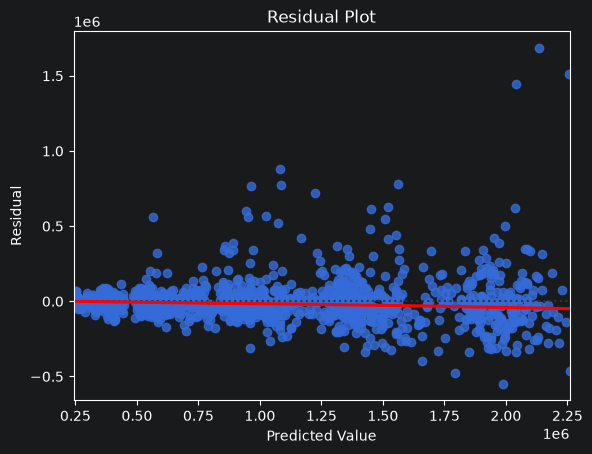

In [364]:
sns.residplot(lowess=True, x=true_predic, y=y_test, line_kws={'color':'red'})
plt.title('Residual Plot')
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.show()
plt.show()

We can see a tendency that the bigger values we have the bigger residuals we will get.

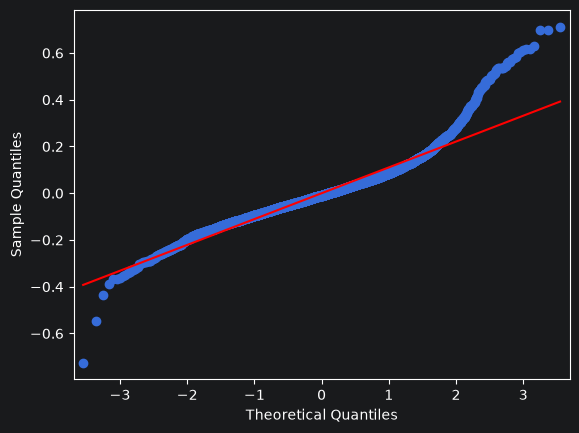

In [45]:
res = model2.resid
sm.qqplot(res, line='r')
plt.show()

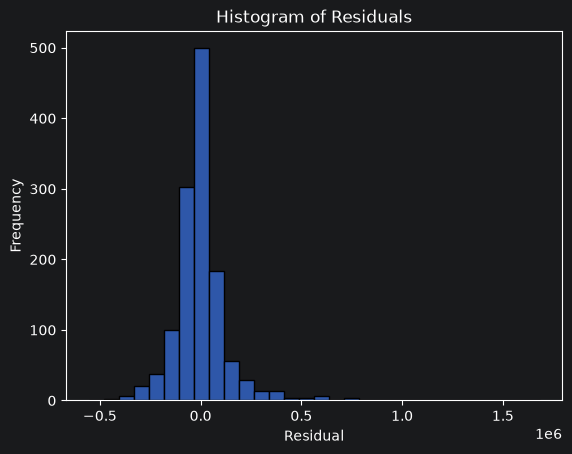

In [50]:
sns.histplot(x=y_test-true_predic, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

Training models on 2010-2011 and testing on 2012

In [365]:
# Creating dummy variables
X = pd.get_dummies(data=X,columns=['Store'], drop_first=True)

w_2010_2011_df = X.loc[X['Year']!=2012]
w_2012_df = X.loc[X['Year']==2012]
assert len(w_2012_df)+len(w_2010_2011_df)==len(X)

In [366]:
w_2010_2011_df.drop('Fuel_Price', axis=1, inplace=True)
w_2012_df.drop('Fuel_Price', axis=1, inplace=True)


w_2010_2011_cols = ['Temperature','CPI','Unemployment','Year','Month','Day']
w_2012_cols = ['Temperature','CPI','Unemployment','Year','Month','Day']
# Scaling
w_2010_2011_df[w_2010_2011_cols] = scaler.fit_transform(w_2010_2011_df[w_2010_2011_cols])
w_2012_df[w_2012_cols] = scaler.transform(w_2012_df[w_2012_cols])

w_2012_df

,Holiday_Flag,Temperature,CPI,Unemployment,Year,Month,Day,Store_2,Store_3,Store_4,...,Store_36,Store_37,Store_38,Store_39,Store_40,Store_41,Store_42,Store_43,Store_44,Store_45
100,0,-0.554163,1.288997,-0.495657,2.962371,-1.761641,-1.092745,False,False,False,...,False,False,False,False,False,False,False,False,False,False
101,0,-0.579512,1.293609,-0.495657,2.962371,-1.761641,-0.295952,False,False,False,...,False,False,False,False,False,False,False,False,False,False
102,0,-0.284828,1.296019,-0.495657,2.962371,-1.761641,0.500841,False,False,False,...,False,False,False,False,False,False,False,False,False,False
103,0,-0.276907,1.298430,-0.495657,2.962371,-1.761641,1.297635,False,False,False,...,False,False,False,False,False,False,False,False,False,False
104,0,-0.155970,1.300840,-0.495657,2.962371,-1.460506,-1.434228,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,0,0.283944,0.572318,0.215496,2.962371,0.647441,1.411462,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6431,0,0.284472,0.576376,0.206446,2.962371,0.948576,-1.206573,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6432,0,-0.265816,0.580434,0.206446,2.962371,0.948576,-0.409779,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6433,0,-0.160195,0.580527,0.206446,2.962371,0.948576,0.387014,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [367]:
M = w_2010_2011_df.copy()
s = walmart_df.loc[X['Year']!=2012,'Weekly_Sales']
k = walmart_df.loc[X['Year']==2012,'Weekly_Sales']
bool_cols = M.select_dtypes(include=['bool']).columns
M[bool_cols] = M[bool_cols].astype('float')

In [368]:
test_model = LinearRegression()
# train_log = np.log1p(s)
# log_k = np.log1p(k)
test_model.fit(M, s)
test_model.score(M, s)
prediction = test_model.predict(w_2012_df)

r2 = r2_score(k, prediction)
r2

# test_model.score(w_2012_df,log_k)

0.950379370713654

In [377]:
M_s = sm.add_constant(M)
t_model = sm.OLS(exog=M_s,endog=s).fit()
prep_w_2012_df = sm.add_constant(w_2012_df,has_constant='add')
prep_w_2012_df = prep_w_2012_df.reindex(columns=M_s.columns,fill_value=0)
prediction_stats = t_model.predict(prep_w_2012_df)
print(t_model.summary())

residuals_stats = prediction_stats-k
# print(prediction.mean())
# print(prediction_stats.mean())

                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     948.3
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:02:42   Log-Likelihood:                -60504.
No. Observations:                4500   AIC:                         1.211e+05
Df Residuals:                    4448   BIC:                         1.214e+05
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         8.202e+05   1.37e+05      5.999   

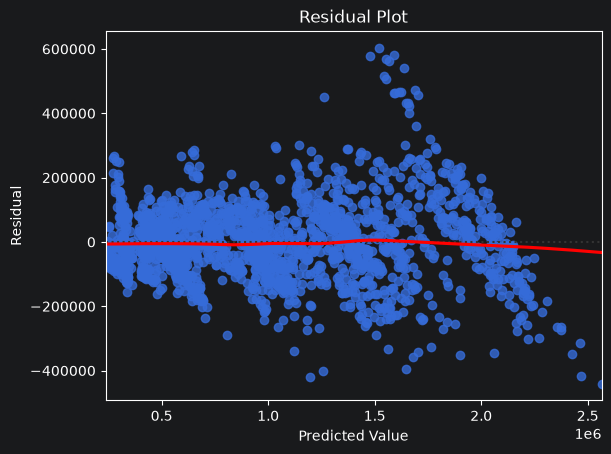

In [238]:
sns.residplot(x=k,y=prediction,lowess=True, line_kws={'color':'red'})
plt.title("Residual Plot")
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.show()

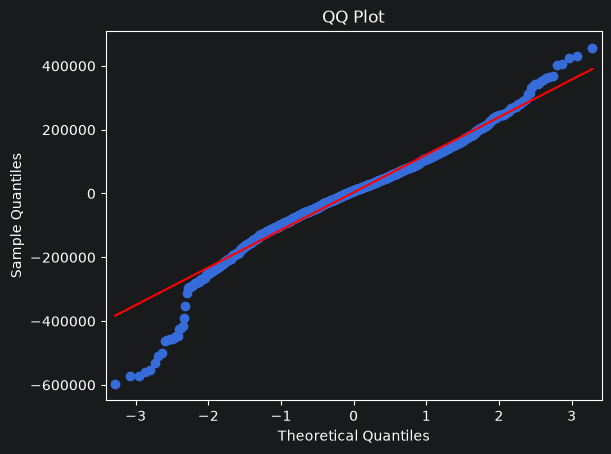

In [254]:
resid = k-prediction
sm.qqplot(resid, line='r')
plt.title('QQ Plot')
plt.show()

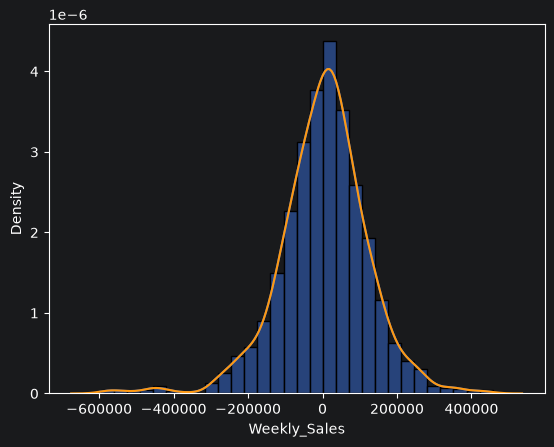

In [272]:
sns.histplot(x=resid, bins=30, stat="density", kde=True)
sns.kdeplot(x=resid, color='#f919')
plt.show()